### Notebook to render the behavior and movement of the agents



In [403]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
from abmax.structs import Params
from matplotlib.patches import FancyArrowPatch

import seaborn as sns
sns.set_theme(style="darkgrid")
palette = "viridis"
sns.set_palette(palette)

#RENDER_DATA_PATH = "../simple_abm/data/wolf_vs_rand13/"
RENDER_DATA_PATH = "./data//"
MAX_SPAWN_X = 500.0
MAX_SPAWN_Y = 500.0
WORLD_SIZE_X = 500.0
WORLD_SIZE_Y = 500.0
SHEEP_RADIUS = 5.0
WOLF_RADIUS = 5.0
GRASS_RADIUS = 1000.0
EP_LEN = 12000
NUM_SHEEP = 250
NUM_WOLF = 200

In [404]:
def load_render_data(filenames):
    return {name: jnp.load(RENDER_DATA_PATH + fname) for name, fname in filenames.items()}

file_map = {
    'sheep_xs': 'rendering_sheep_xs.npy',
    'sheep_ys': 'rendering_sheep_ys.npy',
    'sheep_angs': 'rendering_sheep_angs.npy',
    'wolf_xs': 'rendering_wolf_xs.npy',
    'wolf_ys': 'rendering_wolf_ys.npy',
    'wolf_angs': 'rendering_wolf_angs.npy'
}

import os
for name, fname in file_map.items():
    full_path = os.path.join(RENDER_DATA_PATH, fname)
    print(f"Checking {full_path}: {os.path.exists(full_path)}")

#data = load_render_data(file_map)

Checking ../LV_abm/data/lv_test2/rendering_sheep_xs.npy: True
Checking ../LV_abm/data/lv_test2/rendering_sheep_ys.npy: True
Checking ../LV_abm/data/lv_test2/rendering_sheep_angs.npy: True
Checking ../LV_abm/data/lv_test2/rendering_wolf_xs.npy: True
Checking ../LV_abm/data/lv_test2/rendering_wolf_ys.npy: True
Checking ../LV_abm/data/lv_test2/rendering_wolf_angs.npy: True


In [405]:
def load_render_data(filenames):
    # This maps the file on your SSD to a virtual array
    # without actually 'reading' the bits until you use them.
    return {name: jnp.load(os.path.join(RENDER_DATA_PATH, fname), mmap_mode='r')
            for name, fname in filenames.items()}

data = load_render_data(file_map)
print("Data loaded successfully!")

Data loaded successfully!


In [406]:
print(*(f"{k}: {v.shape}" for k, v in data.items()))

sheep_xs: (1, 3000, 250, 1) sheep_ys: (1, 3000, 250, 1) sheep_angs: (1, 3000, 250, 1) wolf_xs: (1, 3000, 200, 1) wolf_ys: (1, 3000, 200, 1) wolf_angs: (1, 3000, 200, 1)


In [387]:
def select_episode(data, gen_idx, world_idx):
    """Select a single environment and episode from the full dataset."""
    sheep_xs = jnp.squeeze(data['sheep_xs'][gen_idx, world_idx])
    sheep_ys = jnp.squeeze(data['sheep_ys'][gen_idx, world_idx])
    sheep_angs = jnp.squeeze(data['sheep_angs'][gen_idx, world_idx])

    wolf_xs = jnp.squeeze(data['wolf_xs'][gen_idx, world_idx])
    wolf_ys = jnp.squeeze(data['wolf_ys'][gen_idx, world_idx])
    wolf_angs = jnp.squeeze(data['wolf_angs'][gen_idx, world_idx])

    return {
        'sheep_xs': sheep_xs,
        'sheep_ys': sheep_ys,
        'sheep_angs': sheep_angs,
        'wolf_xs': wolf_xs,
        'wolf_ys': wolf_ys,
        'wolf_angs': wolf_angs
    }
gen_idx, world_idx = 0, 0
# gen, world
episode_data = select_episode(data, gen_idx, world_idx)

#print(*(f"{k}: {v.shape}" for k, v in episode_data.items()))

In [407]:
def select_episode(data):
    """Select a single environment and episode from the full dataset."""
    # Just squeeze out the extra dimensions to get (12000, 250)
    sheep_xs = jnp.squeeze(data['sheep_xs'])
    sheep_ys = jnp.squeeze(data['sheep_ys'])
    sheep_angs = jnp.squeeze(data['sheep_angs'])

    wolf_xs = jnp.squeeze(data['wolf_xs'])
    wolf_ys = jnp.squeeze(data['wolf_ys'])
    wolf_angs = jnp.squeeze(data['wolf_angs'])

    return {
        'sheep_xs': sheep_xs,
        'sheep_ys': sheep_ys,
        'sheep_angs': sheep_angs,
        'wolf_xs': wolf_xs,
        'wolf_ys': wolf_ys,
        'wolf_angs': wolf_angs
    }

episode_data = select_episode(data)

print(*(f"{k}: {v.shape}" for k, v in episode_data.items()))

sheep_xs: (3000, 250) sheep_ys: (3000, 250) sheep_angs: (3000, 250) wolf_xs: (3000, 200) wolf_ys: (3000, 200) wolf_angs: (3000, 200)


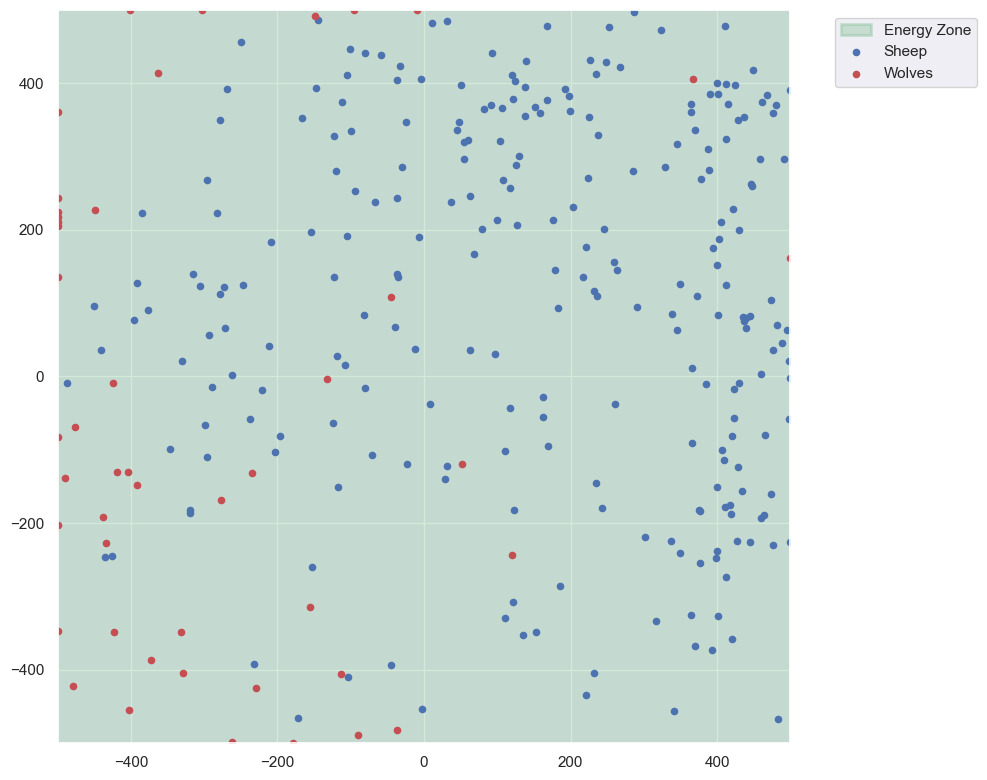

In [408]:
def render_one_traj(render_data):
    """Render a single trajectory of sheep, wolves, and grass."""
    sheep_xs = render_data['sheep_xs']
    sheep_ys = render_data['sheep_ys']

    wolf_xs = render_data['wolf_xs']
    wolf_ys = render_data['wolf_ys']

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(-WORLD_SIZE_X, WORLD_SIZE_X)
    ax.set_ylim(-WORLD_SIZE_Y, WORLD_SIZE_Y)
    ax.set_aspect('equal')

    # energy zone (grass)
    grass_circle = Circle((0, 0),
                      GRASS_RADIUS,
                      linewidth=2, edgecolor='g', facecolor='g', alpha=0.25, label='Energy Zone')
    ax.add_patch(grass_circle)

    # initial scatter plots for sheep and wolves
    sheep_scatter = ax.scatter(sheep_xs[0], sheep_ys[0], c='b', s=SHEEP_RADIUS*4, label='Sheep')
    wolf_scatter = ax.scatter(wolf_xs[0], wolf_ys[0], c='r', s=WOLF_RADIUS*4, label='Wolves')

    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    fig.tight_layout()

    # update function for animation
    def update(frame):
        # Update positions for scatter points
        sheep_scatter.set_offsets(jnp.stack([sheep_xs[frame], sheep_ys[frame]], axis=-1))
        wolf_scatter.set_offsets(jnp.stack([wolf_xs[frame], wolf_ys[frame]], axis=-1))

        return sheep_scatter, wolf_scatter

    ani = FuncAnimation(fig, update, frames=sheep_xs.shape[0], blit=True)
    ani.save('./rand_lv2.mp4', writer='ffmpeg', fps=10)

# Render the selected episode
render_one_traj(episode_data)

## Ignore the following for now

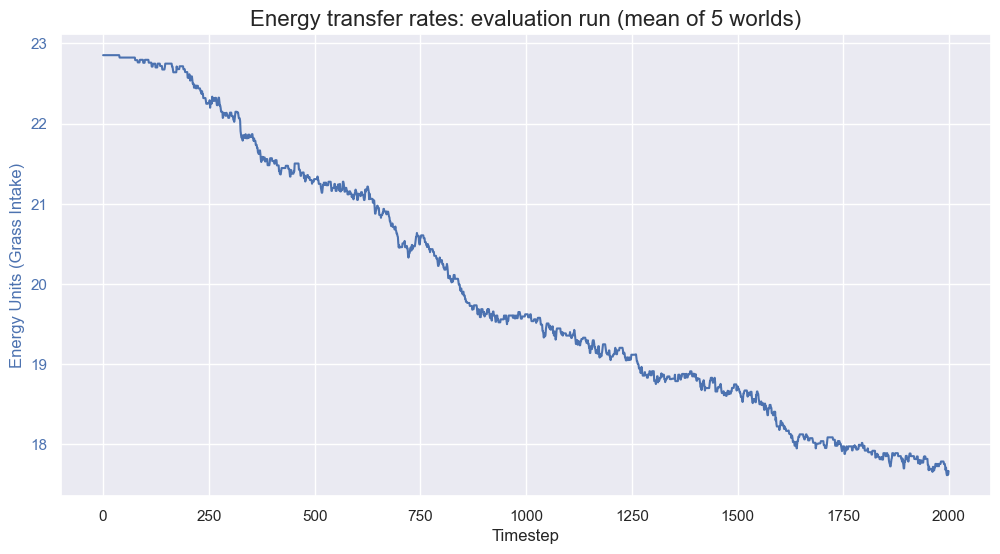

In [323]:
# plot transfer rates

grass_to_sheep = jnp.load(os.path.join(RENDER_DATA_PATH, 'rendering_sheep_transfer_rate.npy'))
sheep_to_wolf = jnp.load(os.path.join(RENDER_DATA_PATH, 'rendering_wolf_energy_transfer.npy'))

grass_to_sheep = jnp.squeeze(grass_to_sheep, axis=0)
sheep_to_wolf = jnp.squeeze(sheep_to_wolf, axis=0)

timesteps = jnp.arange(grass_to_sheep.shape[1])

fig, ax1 = plt.subplots(figsize=(12, 6))
# Plot Grass -> Sheep
# plot the mean across the 5 worlds with a shaded area for variance
mean_grass = jnp.mean(grass_to_sheep, axis=0)
#std_grass = jnp.std(grass_to_sheep, axis=0)

ax1.plot(timesteps, mean_grass, color='b', label='Grass -> Sheep (Foraging)')
#ax1.fill_between(timesteps, mean_grass - std_grass, mean_grass + std_grass, color='green', alpha=0.2)
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Energy Units (Grass Intake)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

"""
# create a second y-axis for Wolf intake if the scales are very different
ax2 = ax1.twinx()
# Plot Sheep -> Wolf
mean_wolf = jnp.mean(sheep_to_wolf, axis=0)
#std_wolf = jnp.std(sheep_to_wolf, axis=0)

ax2.plot(timesteps, mean_wolf, color='r', label='Sheep -> Wolf (Hunting)')
#ax2.fill_between(timesteps, mean_wolf - std_wolf, mean_wolf + std_wolf, color='red', alpha=0.1)
ax2.set_ylabel('Energy Units (Wolf Intake)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
"""

plt.title('Energy transfer rates: evaluation run (mean of 5 worlds)', fontsize=16)
#fig.tight_layout()
plt.show()

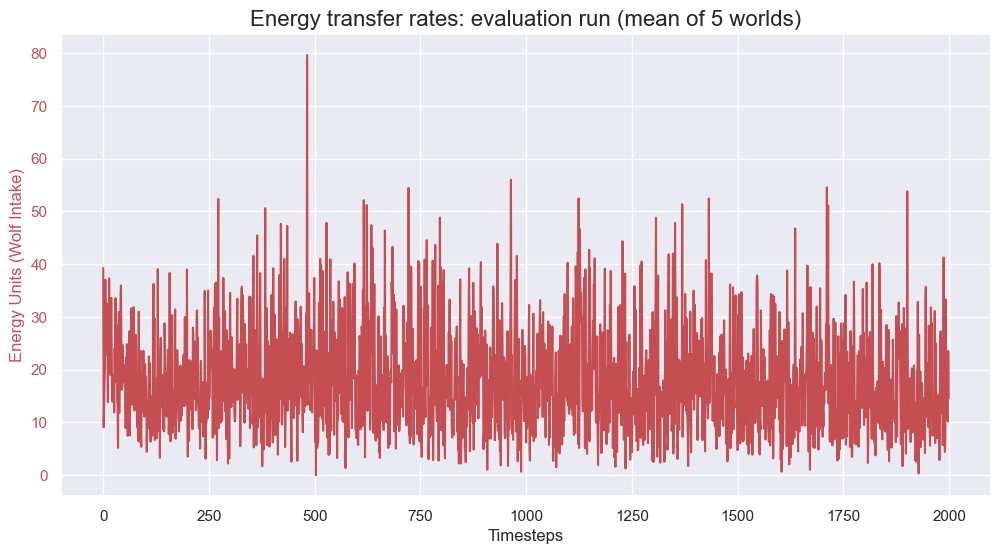

In [324]:
# plot wolf transfer rate
grass_to_sheep = jnp.load(os.path.join(RENDER_DATA_PATH, 'rendering_sheep_transfer_rate.npy'))
sheep_to_wolf = jnp.load(os.path.join(RENDER_DATA_PATH, 'rendering_wolf_energy_transfer.npy'))

grass_to_sheep = jnp.squeeze(grass_to_sheep, axis=0)
sheep_to_wolf = jnp.squeeze(sheep_to_wolf, axis=0)

mean_wolf = jnp.mean(sheep_to_wolf, axis=0)

timesteps = jnp.arange(grass_to_sheep.shape[1])

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(timesteps, mean_wolf, color='r', label='Sheep -> Wolves')
#ax1.fill_between(timesteps, mean_grass - std_grass, mean_grass + std_grass, color='green', alpha=0.2)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Energy Units (Wolf Intake)', color='r')
ax1.tick_params(axis='y', labelcolor='r')

plt.title('Energy transfer rates: evaluation run (mean of 5 worlds)', fontsize=16)
#fig.tight_layout()
plt.show()

In [11]:
# ignore for now

# Save snapshot
sheep_xs = jnp.squeeze(data['sheep_xs'][env_idx, ep_idx]).T
sheep_ys = jnp.squeeze(data['sheep_ys'][env_idx, ep_idx]).T
sheep_angs = jnp.squeeze(data['sheep_angs'][env_idx, ep_idx]).T

wolf_xs = jnp.squeeze(data['wolf_xs'][env_idx, ep_idx]).T
wolf_ys = jnp.squeeze(data['wolf_ys'][env_idx, ep_idx]).T
wolf_angs = jnp.squeeze(data['wolf_angs'][env_idx, ep_idx]).T


print(sheep_xs.shape, sheep_ys.shape, sheep_angs.shape,
      wolf_xs.shape, wolf_ys.shape, wolf_angs.shape)

# Initial positions (frame 0)
sheep_init_xs = sheep_xs[:, 0]
sheep_init_ys = sheep_ys[:, 0]
sheep_init_angs = sheep_angs[:, 0]

wolf_init_xs = wolf_xs[:, 0]
wolf_init_ys = wolf_ys[:, 0]
wolf_init_angs = wolf_angs[:, 0]


fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-MAX_SPAWN_X, MAX_SPAWN_X)
ax.set_ylim(-MAX_SPAWN_Y, MAX_SPAWN_Y)
ax.set_aspect('equal')
ax.tick_params(axis='both', which='major', labelsize=20)

# Scatter plots
sheep_scatter = ax.scatter(sheep_init_xs, sheep_init_ys, c='b', s=SHEEP_RADIUS*4, label='Sheep')
wolf_scatter = ax.scatter(wolf_init_xs, wolf_init_ys, c='r', s=WOLF_RADIUS*4, label='Wolves')

# Quiver for sheep directions
sheep_quiver = ax.quiver(
    sheep_init_xs, sheep_init_ys,
    jnp.cos(sheep_init_angs), jnp.sin(sheep_init_angs),
    color='indigo', scale=80.0
)
wolf_quiver = ax.quiver(
    wolf_init_xs, wolf_init_ys,
    jnp.cos(wolf_init_angs), jnp.sin(wolf_init_angs),
    color='darkred', scale=80.0
)

# Create an invisible arrow patch for the legend
sheep_arrow_patch = FancyArrowPatch(
    (0, 0), (1, 0),
    color='indigo', alpha=0.0,
    mutation_scale=15,  # Arrow head size
    linewidth=1.5,
    arrowstyle='->',
    label='Sheep directions'
)
wolf_arrow_patch = FancyArrowPatch(
    (0, 0), (1, 0),
    color='darkred', alpha=0.0,
    mutation_scale=15,
    linewidth=1.5,
    arrowstyle='->',
    label='Wolf directions'
)


# Legend
ax.legend(
    [sheep_scatter, wolf_scatter, sheep_arrow_patch, wolf_arrow_patch],
    ['Grasses', 'Sheep', 'Wolves', 'Sheep directions', 'Wolf directions'],
    loc='upper left', fontsize=18
)

# Save figure
plt.savefig('./sheep_wolf_scatter_image.svg', bbox_inches='tight')
plt.close(fig)

(20, 300) (20, 300) (20, 300) (20, 300) (20, 300) (20, 300)
